The probability density function of two 1D Gaussians with variances $\sigma_1^2$, $\sigma_2^2$, means $\mu_1$, $\mu_2$, and mixture fraction $\pi$:
\begin{equation}
    P(x) = \pi \cdot \mathcal{N}(x|\mu_1, \sigma_1^2) + (1-\pi) \cdot \mathcal{N}(x|\mu_2, \sigma_2^2)
\end{equation}

As a second piece, we need the negative log-likelihood:
\begin{equation}
    \text{NLL} = -\sum{}{}{\log{P(x)}}
\end{equation}

Using pretty much any optimizer, we can then fit a GMM by minimizing the NLL:
\begin{equation}
    \argmin_{\sigma_1^2, \sigma_2^2, \pi}{(\text{NLL})}
\end{equation}

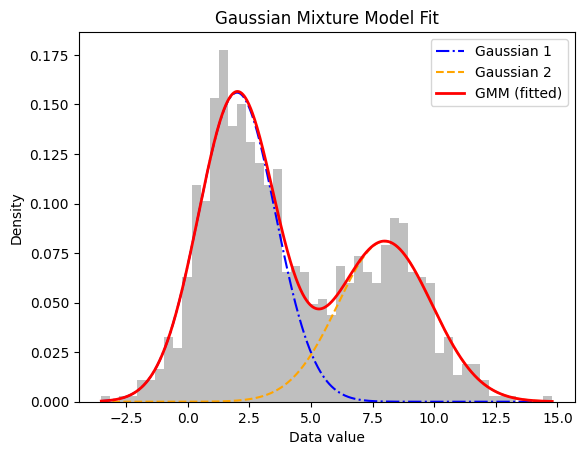

In [41]:
from pyfraglib.math import fit_gmm, plot_gmm
import numpy as np
import numpy.typing as npt

mean1 = 2.0
mean2 = 8.0
fixed_means: tuple[float, float] = (mean1, mean2)

std1 = 1.5
std2 = 2.0
pi_true = 0.6

data1: npt.NDArray[np.float64] = np.random.normal(loc=mean1, scale=std1, size=int(1000 * pi_true))
data2: npt.NDArray[np.float64] = np.random.normal(loc=mean2, scale=std2, size=int(1000 * (1 - pi_true)))
data: npt.NDArray[np.float64] = np.hstack([data1, data2])  # type: ignore

pi_est, std1_est, std2_est = fit_gmm(mean1, mean2, data)
plot_gmm(data, mean1, mean2, pi_est, std1_est, std2_est)